
# SLAP2 super-stack presentation rendering — red/blue, visible structures

This notebook makes a presentation-friendly rendering of a merged SLAP2 super-stack.

Compared with the previous version, this one defaults to an **oblique MIP-style rendering** rather than opacity accumulation. That is usually much better for dense structural data because it avoids both failure modes:

- an opaque blown-out red/blue slab from too much accumulated opacity,
- a nearly black image from overly aggressive opacity/thresholding.

The output colors are:

- **DMD1 / superficial = warm red-salmon**
- **DMD2 / deep = dodger blue**

The main output is saved as a PNG/PDF for slide use.


In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy.ndimage import rotate, zoom, gaussian_filter

warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['figure.facecolor'] = 'black'


## 1. Configure paths

In [2]:

# --- REQUIRED: set these to your dataset ---
ROOT_DIR = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data")
MANIFEST_PATH = ROOT_DIR / 'super_stack_manifest.tsv'  # optional; can also be a local TSV path

# If your outputs live somewhere else, point here explicitly:
MERGE_DIR = ROOT_DIR / "super_stack_qc" / "full_reference_merge"
OUT_DIR = MERGE_DIR / "presentation_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("MERGE_DIR:", MERGE_DIR)
print("OUT_DIR:", OUT_DIR)


ROOT_DIR: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data
MERGE_DIR: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge
OUT_DIR: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge\presentation_figures


## 2. Rendering parameters

In [42]:

# Colors matching your schematic / Data Club color language.
DMD1_COLOR = "#F29B7B"   # warm salmon / red-orange, superficial / upper plane
DMD2_COLOR = "#1E90FF"   # dodger blue, deeper / lower plane

# Geometry / viewing controls.
DOWNSAMPLE_XY = 1         # 1 = highest quality but slower; 2 is usually enough for slides
Z_SCALE_BOOST = 1      # <1 visually compresses Z; increase for thicker side-view
TILT_X_DEG = 20           # reveal depth
TILT_Z_DEG = 10          # in-plane angle
PROJECTION_AXIS = 1       # after rotation, 1 often gives a nice side/oblique projection

# Contrast controls. These defaults are intentionally brighter than the previous notebook.
BACKGROUND_SUBTRACT = True
BACKGROUND_SIGMA_YX = 8   # broad XY haze subtraction after downsampling
LOW_Q = 5              # lower = more dim dendrites included
HIGH_Q = 99.99            # high clipping; lower if somata dominate
GAMMA = 1             # <1 brightens dim dendrites
SIGNAL_FLOOR = 0.01       # weak-signal floor after normalization
PROJECTION_GAIN = 1.0     # final brightness boost after MIP
PROJECTION_GAMMA = 0.9   # final display gamma on projected image

# Figure/export options.
SHOW_LABELS = True
SAVE_TRANSPARENT = True


## 3. Helper functions

In [10]:

def find_merge_files_from_manifest(root_dir, manifest_path=None, merge_dir=None):
    """Return paths to the main merge outputs."""
    if merge_dir is not None:
        merge_dir = Path(merge_dir)
        return {
            'dmd1': merge_dir / 'dmd1_warped_ch1.tif',
            'dmd2': merge_dir / 'dmd2_warped_ch1.tif',
            'summary': merge_dir / 'slap2_super_stack_merge_summary.json',
            'super': merge_dir / 'slap2_super_stack_ch1.tif',
            'weights': merge_dir / 'merge_weights.tif',
        }

    if manifest_path is None:
        raise ValueError('Need either merge_dir or manifest_path.')

    df = pd.read_csv(manifest_path, sep='	')
    rels = df.iloc[:, 0].astype(str).tolist()

    def pick(suffix):
        matches = [r for r in rels if r.endswith(suffix)]
        if not matches:
            raise FileNotFoundError(f'Could not find {suffix} in manifest')
        return root_dir / matches[0]

    return {
        'dmd1': pick(r'super_stack_qc\full_reference_merge\dmd1_warped_ch1.tif'),
        'dmd2': pick(r'super_stack_qc\full_reference_merge\dmd2_warped_ch1.tif'),
        'summary': pick(r'super_stack_qc\full_reference_merge\slap2_super_stack_merge_summary.json'),
        'super': pick(r'super_stack_qc\full_reference_merge\slap2_super_stack_ch1.tif'),
        'weights': pick(r'super_stack_qc\full_reference_merge\merge_weights.tif'),
    }


def nonzero_bbox(vol1, vol2, pad=(4, 24, 24), min_value=0):
    """Bounding box around nonzero/valid signal in the union of two volumes."""
    m = (np.nan_to_num(vol1) > min_value) | (np.nan_to_num(vol2) > min_value)
    coords = np.argwhere(m)
    if coords.size == 0:
        return tuple(slice(0, s) for s in vol1.shape)
    mins = coords.min(axis=0)
    maxs = coords.max(axis=0) + 1
    mins = np.maximum(mins - np.array(pad), 0)
    maxs = np.minimum(maxs + np.array(pad), np.array(vol1.shape))
    return tuple(slice(int(a), int(b)) for a, b in zip(mins, maxs))


def robust_normalize_positive(vol, low_q=5.0, high_q=99.85, gamma=0.55, signal_floor=0.01):
    """Clip positive values by quantile, normalize, gamma-adjust, and threshold weak haze."""
    vol = np.asarray(vol, dtype=np.float32)
    vol = np.nan_to_num(vol, nan=0.0, posinf=0.0, neginf=0.0)
    vol[vol < 0] = 0

    vals = vol[vol > 0]
    if vals.size == 0:
        return np.zeros_like(vol, dtype=np.float32)

    lo, hi = np.percentile(vals, [low_q, high_q])
    if hi <= lo:
        hi = lo + 1e-6

    out = np.clip((vol - lo) / (hi - lo), 0, 1)
    out = out ** gamma
    out[out < signal_floor] = 0
    return out.astype(np.float32)


def prepare_for_render(
    vol,
    bbox,
    *,
    downsample_xy=2,
    xy_um=0.25,
    z_um=1.5,
    z_scale_boost=0.45,
    background_subtract=True,
    background_sigma_yx=8,
    low_q=5.0,
    high_q=99.85,
    gamma=0.55,
    signal_floor=0.01,
):
    """Crop, downsample, visually z-scale, background subtract, and normalize a volume."""
    v = np.asarray(vol[bbox], dtype=np.float32)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)

    if downsample_xy and downsample_xy > 1:
        v = zoom(v, (1.0, 1.0 / downsample_xy, 1.0 / downsample_xy), order=1)
        xy_eff = xy_um * downsample_xy
    else:
        xy_eff = xy_um

    z_factor = (z_um / xy_eff) * z_scale_boost
    if z_factor != 1.0:
        v = zoom(v, (z_factor, 1.0, 1.0), order=1)

    if background_subtract:
        bg = gaussian_filter(v, sigma=(0, background_sigma_yx, background_sigma_yx))
        v = v - bg
        v[v < 0] = 0

    v = robust_normalize_positive(
        v,
        low_q=low_q,
        high_q=high_q,
        gamma=gamma,
        signal_floor=signal_floor,
    )
    return v.astype(np.float32), xy_eff, z_factor


def rotate_for_view(v, tilt_x_deg=18, tilt_z_deg=-20):
    """Rotate volume into an oblique side-view orientation."""
    vr = rotate(v, angle=tilt_x_deg, axes=(0, 1), reshape=True, order=1, mode='constant', cval=0)
    vr = rotate(vr, angle=tilt_z_deg, axes=(1, 2), reshape=True, order=1, mode='constant', cval=0)
    return vr.astype(np.float32)


def colorize_projection(p, color, gain=3.0, projection_gamma=0.75):
    """Apply display gamma/gain and map a scalar projection to RGB."""
    p = np.clip(p, 0, 1)
    p = np.clip((p ** projection_gamma) * gain, 0, 1)
    c = np.asarray(to_rgb(color), dtype=np.float32)
    return p[..., None] * c[None, None, :], p


def render_oblique_mip(
    dmd1,
    dmd2,
    *,
    xy_um=0.25,
    z_um=1.5,
    dmd1_color="#F29B7B",
    dmd2_color="#1E90FF",
    downsample_xy=2,
    z_scale_boost=0.45,
    tilt_x_deg=18,
    tilt_z_deg=-20,
    projection_axis=1,
    background_subtract=True,
    background_sigma_yx=8,
    low_q=5.0,
    high_q=99.85,
    gamma=0.55,
    signal_floor=0.01,
    projection_gain=3.0,
    projection_gamma=0.75,
):
    """Make an oblique colored MIP-style rendering of DMD1 and DMD2."""
    bbox = nonzero_bbox(dmd1, dmd2)

    v1, xy_eff, z_factor = prepare_for_render(
        dmd1, bbox,
        downsample_xy=downsample_xy,
        xy_um=xy_um,
        z_um=z_um,
        z_scale_boost=z_scale_boost,
        background_subtract=background_subtract,
        background_sigma_yx=background_sigma_yx,
        low_q=low_q,
        high_q=high_q,
        gamma=gamma,
        signal_floor=signal_floor,
    )
    v2, _, _ = prepare_for_render(
        dmd2, bbox,
        downsample_xy=downsample_xy,
        xy_um=xy_um,
        z_um=z_um,
        z_scale_boost=z_scale_boost,
        background_subtract=background_subtract,
        background_sigma_yx=background_sigma_yx,
        low_q=low_q,
        high_q=high_q,
        gamma=gamma,
        signal_floor=signal_floor,
    )

    v1r = rotate_for_view(v1, tilt_x_deg=tilt_x_deg, tilt_z_deg=tilt_z_deg)
    v2r = rotate_for_view(v2, tilt_x_deg=tilt_x_deg, tilt_z_deg=tilt_z_deg)

    # MIP is intentionally used here because it preserves visible neurites without saturating the slab.
    p1 = np.max(v1r, axis=projection_axis)
    p2 = np.max(v2r, axis=projection_axis)

    rgb1, p1d = colorize_projection(p1, dmd1_color, gain=projection_gain, projection_gamma=projection_gamma)
    rgb2, p2d = colorize_projection(p2, dmd2_color, gain=projection_gain, projection_gamma=projection_gamma)
    rgb = np.clip(rgb1 + rgb2, 0, 1)

    return {
        'rgb': rgb.astype(np.float32),
        'dmd1_projection': p1d.astype(np.float32),
        'dmd2_projection': p2d.astype(np.float32),
        'bbox': bbox,
        'xy_um_effective': xy_eff,
        'z_factor_used': z_factor,
        'dmd1_rotated': v1r,
        'dmd2_rotated': v2r,
    }


def render_oblique_alpha(
    dmd1,
    dmd2,
    *,
    xy_um=0.25,
    z_um=1.5,
    dmd1_color="#F29B7B",
    dmd2_color="#1E90FF",
    opacity_scale=0.10,
    downsample_xy=2,
    z_scale_boost=0.45,
    tilt_x_deg=18,
    tilt_z_deg=-20,
    projection_axis=1,
    **prep_kwargs,
):
    """Optional lower-opacity front-to-back alpha render."""
    bbox = nonzero_bbox(dmd1, dmd2)
    v1, xy_eff, z_factor = prepare_for_render(dmd1, bbox, xy_um=xy_um, z_um=z_um, downsample_xy=downsample_xy,
                                               z_scale_boost=z_scale_boost, **prep_kwargs)
    v2, _, _ = prepare_for_render(dmd2, bbox, xy_um=xy_um, z_um=z_um, downsample_xy=downsample_xy,
                                  z_scale_boost=z_scale_boost, **prep_kwargs)
    v1r = rotate_for_view(v1, tilt_x_deg=tilt_x_deg, tilt_z_deg=tilt_z_deg)
    v2r = rotate_for_view(v2, tilt_x_deg=tilt_x_deg, tilt_z_deg=tilt_z_deg)

    # Front-to-back compositing without squaring intensity.
    c1 = np.asarray(to_rgb(dmd1_color), dtype=np.float32)
    c2 = np.asarray(to_rgb(dmd2_color), dtype=np.float32)
    a1 = np.clip(v1r * opacity_scale, 0, 1)
    a2 = np.clip(v2r * opacity_scale, 0, 1)
    alpha = np.clip(a1 + a2, 0, 1)
    color = (a1[..., None] * c1 + a2[..., None] * c2)

    rgb_stack = np.moveaxis(color, projection_axis, 0)
    alpha_stack = np.moveaxis(alpha, projection_axis, 0)
    out = np.zeros(rgb_stack.shape[1:], dtype=np.float32)
    trans = np.ones(alpha_stack.shape[1:], dtype=np.float32)
    for k in range(rgb_stack.shape[0]):
        a = alpha_stack[k]
        out += trans[..., None] * rgb_stack[k]
        trans *= (1 - a)
    return {'rgb': np.clip(out, 0, 1), 'bbox': bbox, 'xy_um_effective': xy_eff, 'z_factor_used': z_factor}


## 4. Locate merge outputs and load metadata

In [5]:

files = find_merge_files_from_manifest(ROOT_DIR, MANIFEST_PATH, MERGE_DIR)
files


{'dmd1': WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP7/826031/826031_2026-02-04_12-15-34/826031_2026-02-04_12-15-34/slap2/static_data/super_stack_qc/full_reference_merge/dmd1_warped_ch1.tif'),
 'dmd2': WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP7/826031/826031_2026-02-04_12-15-34/826031_2026-02-04_12-15-34/slap2/static_data/super_stack_qc/full_reference_merge/dmd2_warped_ch1.tif'),
 'summary': WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP7/826031/826031_2026-02-04_12-15-34/826031_2026-02-04_12-15-34/slap2/static_data/super_stack_qc/full_reference_merge/slap2_super_stack_merge_summary.json'),
 'super': WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP7/826031/826031_2026-02-04_12-15-34/826031_2026-02-04_12-15-34/slap2/static_data/super_stack_qc/full_reference_merge/slap2_super_stack_ch1.tif'),
 'weights': WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP

In [6]:

with open(files['summary'], 'r') as f:
    summary = json.load(f)

xy_um = 0.25
z_um = 1.5
if 'output_grid' in summary:
    xy_um = float(summary['output_grid'].get('xy_resolution_um', xy_um))
    z_um = float(summary['output_grid'].get('z_resolution_um', z_um))
elif 'config' in summary:
    xy_um = float(summary['config'].get('xy_resolution_um', xy_um))
    z_um = float(summary['config'].get('z_resolution_um', z_um))

print('xy_um =', xy_um)
print('z_um =', z_um)
print('summary keys =', list(summary.keys())[:20])


xy_um = 0.25
z_um = 1.5
summary keys = ['config', 'source_files', 'dmd1', 'dmd2', 'dmd2_effective', 'output_grid', 'z_overlap_um', 'z_registration', 'residual_registration', 'outputs']


## 5. Load DMD volumes

In [7]:

dmd1 = tifffile.imread(files['dmd1']).astype(np.float32)
dmd2 = tifffile.imread(files['dmd2']).astype(np.float32)

print('DMD1:', dmd1.shape, dmd1.dtype, 'min/max:', float(np.nanmin(dmd1)), float(np.nanmax(dmd1)))
print('DMD2:', dmd2.shape, dmd2.dtype, 'min/max:', float(np.nanmin(dmd2)), float(np.nanmax(dmd2)))


DMD1: (176, 1413, 1549) float32 min/max: -1.0 1400.935791015625
DMD2: (176, 1413, 1549) float32 min/max: -1.0 1132.597900390625


## 6. Fast QC: confirm the signal is visible before 3D rendering

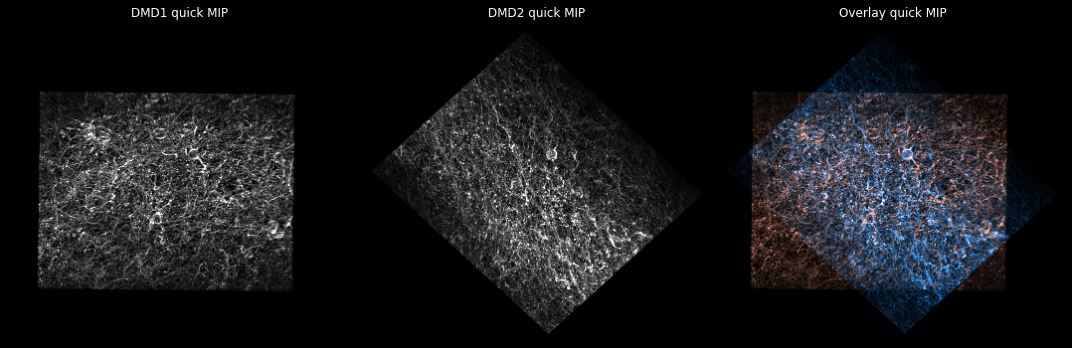

In [15]:

# This cell should always show visible structure. If it is dark, the paths or input files are wrong.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='black')
for ax in axes:
    ax.set_facecolor('black')

bbox = nonzero_bbox(dmd1, dmd2)
small1, _, _ = prepare_for_render(dmd1, bbox, downsample_xy=4, xy_um=xy_um, z_um=z_um,
                                  z_scale_boost=1, background_subtract=True,
                                  low_q=1, high_q=99.99, gamma=0.75, signal_floor=0.0)
small2, _, _ = prepare_for_render(dmd2, bbox, downsample_xy=4, xy_um=xy_um, z_um=z_um,
                                  z_scale_boost=1, background_subtract=True,
                                  low_q=1, high_q=99.99, gamma=0.75, signal_floor=0.0)

p1 = small1.max(axis=0)
p2 = small2.max(axis=0)
rgb_qc = np.clip(p1[..., None] * np.array(to_rgb(DMD1_COLOR)) + p2[..., None] * np.array(to_rgb(DMD2_COLOR)), 0, 1)

axes[0].imshow(p1, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('DMD1 quick MIP', color='white')
axes[1].imshow(p2, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('DMD2 quick MIP', color='white')
axes[2].imshow(rgb_qc)
axes[2].set_title('Overlay quick MIP', color='white')
for ax in axes:
    ax.axis('off')
plt.tight_layout()


## 7. Main oblique MIP rendering

render rgb range: 0.0 1.0
effective xy_um: 0.25
z_factor used: 6.0


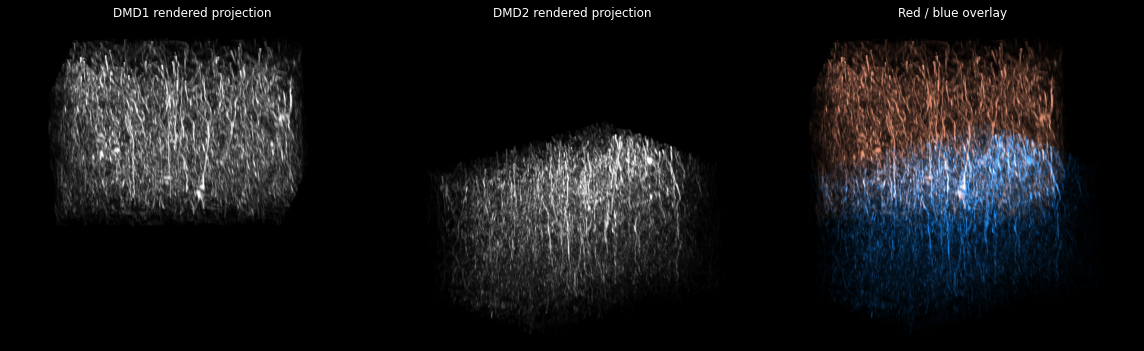

In [43]:

render = render_oblique_mip(
    dmd1,
    dmd2,
    xy_um=xy_um,
    z_um=z_um,
    dmd1_color=DMD1_COLOR,
    dmd2_color=DMD2_COLOR,
    downsample_xy=DOWNSAMPLE_XY,
    z_scale_boost=Z_SCALE_BOOST,
    tilt_x_deg=TILT_X_DEG,
    tilt_z_deg=TILT_Z_DEG,
    projection_axis=PROJECTION_AXIS,
    background_subtract=BACKGROUND_SUBTRACT,
    background_sigma_yx=BACKGROUND_SIGMA_YX,
    low_q=LOW_Q,
    high_q=HIGH_Q,
    gamma=GAMMA,
    signal_floor=SIGNAL_FLOOR,
    projection_gain=PROJECTION_GAIN,
    projection_gamma=PROJECTION_GAMMA,
)

rgb = render['rgb']
print('render rgb range:', float(rgb.min()), float(rgb.max()))
print('effective xy_um:', render['xy_um_effective'])
print('z_factor used:', render['z_factor_used'])

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='black')
for ax in axes:
    ax.set_facecolor('black')

axes[0].imshow(render['dmd1_projection'], cmap='gray', vmin=0, vmax=1)
axes[0].set_title('DMD1 rendered projection', color='white')
axes[0].axis('off')

axes[1].imshow(render['dmd2_projection'], cmap='gray', vmin=0, vmax=1)
axes[1].set_title('DMD2 rendered projection', color='white')
axes[1].axis('off')

axes[2].imshow(rgb)
axes[2].set_title('Red / blue overlay', color='white')
axes[2].axis('off')

plt.tight_layout()


## 8. Slide-ready export

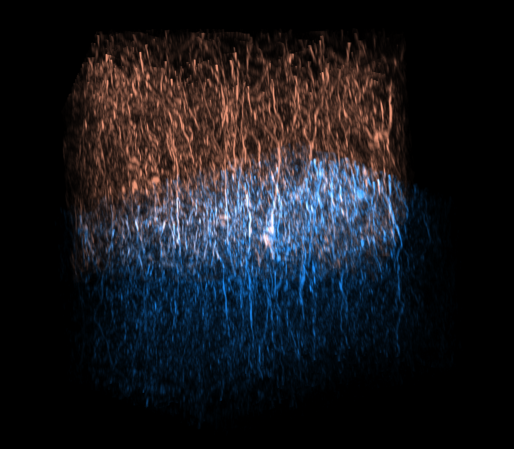

\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge\presentation_figures\slap2_superstack_oblique_merge.png
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge\presentation_figures\slap2_superstack_oblique_merge.pdf


In [44]:

fig, ax = plt.subplots(figsize=(9, 8), facecolor='black')
ax.set_facecolor('black')
ax.imshow(rgb)
ax.axis('off')

# if SHOW_LABELS:
#     ax.text(
#         0.03, 0.96,
#         'SLAP2 super-stack merge',
#         transform=ax.transAxes,
#         va='top', ha='left', color='white', fontsize=20,
#     )
#     ax.text(
#         0.03, 0.90,
#         'DMD1 / superficial = red    DMD2 / deep = blue',
#         transform=ax.transAxes,
#         va='top', ha='left', color='white', fontsize=13,
#     )
#     ax.text(
#         0.03, 0.04,
#         f'xy = {xy_um:.2f} µm/px   z = {z_um:.2f} µm/plane',
#         transform=ax.transAxes,
#         va='bottom', ha='left', color='white', fontsize=11,
#         bbox=dict(boxstyle='round,pad=0.25', fc=(0,0,0,0.35), ec='none')
#     )

out_png = OUT_DIR / 'slap2_superstack_oblique_merge.png'
out_pdf = OUT_DIR / 'slap2_superstack_oblique_merge.pdf'
fig.savefig(out_png, bbox_inches='tight', pad_inches=0.04, facecolor=fig.get_facecolor())
fig.savefig(out_pdf, bbox_inches='tight', pad_inches=0.04, facecolor=fig.get_facecolor())
plt.show()

print(out_png)
print(out_pdf)


## 9. Optional transparent export

FileNotFoundError: [Errno 2] No such file or directory: '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\ASAP7\\826031\\826031_2026-02-04_12-15-34\\826031_2026-02-04_12-15-34\\slap2\\static_data\\super_stack_qc\\full_reference_merge\\presentation_figures\\slap2_superstack_oblique_merge_red_blue_VISIBLE_transparent.png'

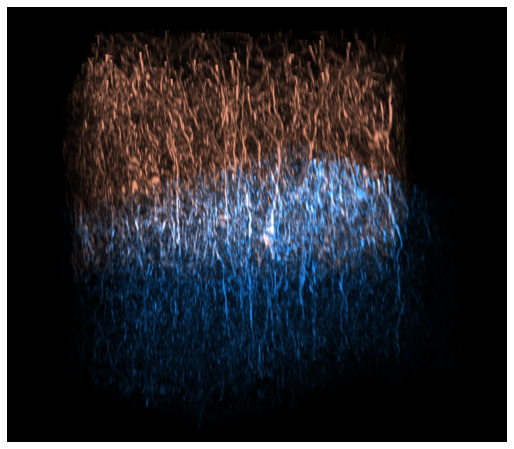

In [45]:

if SAVE_TRANSPARENT:
    fig, ax = plt.subplots(figsize=(9, 8), facecolor='none')
    ax.imshow(rgb)
    ax.axis('off')
    transparent_png = OUT_DIR / 'slap2_superstack_oblique_merge_red_blue_VISIBLE_transparent.png'
    fig.savefig(transparent_png, bbox_inches='tight', pad_inches=0.02, transparent=True)
    plt.show()
    print(transparent_png)


## 10. If it is still too dark or too bright

In [ ]:

print('If output is too dark:')
print('  PROJECTION_GAIN = 5.0')
print('  LOW_Q = 1.0')
print('  GAMMA = 0.40')
print('  SIGNAL_FLOOR = 0.0')
print('  BACKGROUND_SUBTRACT = False')
print()
print('If output is too bright / slab-like:')
print('  PROJECTION_GAIN = 1.5')
print('  LOW_Q = 15.0')
print('  GAMMA = 0.80')
print('  SIGNAL_FLOOR = 0.03')
print('  BACKGROUND_SUBTRACT = True')
print('  BACKGROUND_SIGMA_YX = 12')
print()
print('If the view is too flat:')
print('  TILT_X_DEG = 22')
print('  Z_SCALE_BOOST = 0.6')
print()
print('If the volume looks too thick / cube-like:')
print('  Z_SCALE_BOOST = 0.3')
